In [33]:
import re
import pandas as pd
import numpy as np

import lasio
import segyio

import matplotlib.pyplot as plt

In [2]:
boreas_1_owt = lasio.read('data_poseidon/boreas_owt.las')
boreas_1_owt_df = boreas_1_owt.df()

In [3]:
boreas_1_porosity_trace = pd.read_fwf('data_poseidon/boreas_porosity_trace.txt', widths=[23, 17, 17, 17, 17,17, 17, 17, 17, 17,17, 17, 17, 17, 17,17, 17])

In [4]:
boreas_1_porosity_trace = boreas_1_porosity_trace.drop(boreas_1_porosity_trace.index[0]).reindex()

In [5]:
boreas_1_porosity_trace

,MD,Trace,Trace.1,Trace.2,Trace.3,Trace.4,Trace.5,Trace.6,Trace.7,Trace.8,Trace.9,Trace.10,Trace.11,Trace.12,Trace.13,Trace.14,Trace.15
1,11782.00000000,0.058959,0.058822,0.058684,0.058546,0.058470,0.058496,0.058522,0.058549,0.058579,0.058611,0.058643,0.058674,0.058680,0.058686,0.058691,0.058693
2,11782.50000000,0.058959,0.058822,0.058684,0.058546,0.058470,0.058496,0.058522,0.058549,0.058579,0.058611,0.058643,0.058674,0.058680,0.058686,0.058691,0.058693
3,11783.00000000,0.058959,0.058822,0.058684,0.058546,0.058470,0.058496,0.058522,0.058549,0.058579,0.058611,0.058643,0.058674,0.058680,0.058686,0.058691,0.058693
4,11783.50000000,0.058959,0.058822,0.058684,0.058546,0.058470,0.058496,0.058522,0.058549,0.058579,0.058611,0.058643,0.058674,0.058680,0.058686,0.058691,0.058693
5,11784.00000000,0.058959,0.058822,0.058684,0.058546,0.058470,0.058496,0.058522,0.058549,0.058579,0.058611,0.058643,0.058674,0.058680,0.058686,0.058691,0.058693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10620,17091.50000000,0.041553,0.041867,0.042223,0.042569,0.042872,0.043095,0.043296,0.043380,0.043453,0.043493,0.043452,0.043405,0.043340,0.043223,0.043105,0.042990
10621,17092.00000000,0.041442,0.041753,0.042105,0.042447,0.042745,0.042965,0.043162,0.043244,0.043314,0.043351,0.043310,0.043263,0.043198,0.043083,0.042968,0.042855
10622,17092.50000000,0.041332,0.041640,0.041988,0.042325,0.042619,0.042835,0.043028,0.043107,0.043174,0.043209,0.043167,0.043120,0.043055,0.042943,0.042831,0.042722
10623,17093.00000000,0.041222,0.041526,0.041870,0.042204,0.042492,0.042705,0.042894,0.042970,0.043034,0.043067,0.043025,0.042977,0.042913,0.042803,0.042693,0.042588


In [6]:
boreas_1_porosity_trace['MD'] = boreas_1_porosity_trace['MD'].astype(float)

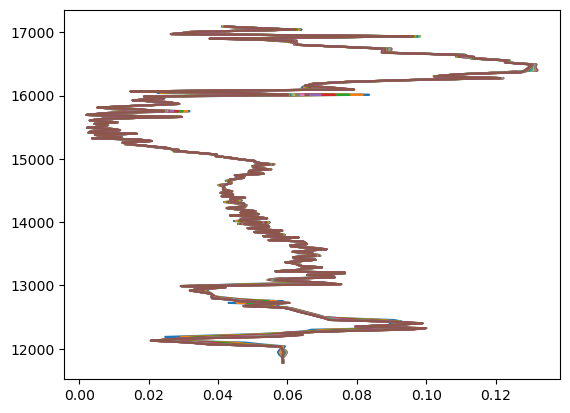

In [11]:
fig, ax = plt.subplots(1,1,)

ax.plot(boreas_1_porosity_trace['Trace'], boreas_1_porosity_trace['MD'])
ax.plot(boreas_1_porosity_trace['Trace.1'], boreas_1_porosity_trace['MD'])
ax.plot(boreas_1_porosity_trace['Trace.2'], boreas_1_porosity_trace['MD'])
ax.plot(boreas_1_porosity_trace['Trace.3'], boreas_1_porosity_trace['MD'])
ax.plot(boreas_1_porosity_trace['Trace.4'], boreas_1_porosity_trace['MD'])
ax.plot(boreas_1_porosity_trace['Trace.5'], boreas_1_porosity_trace['MD'])
ax.plot(boreas_1_porosity_trace['Trace.6'], boreas_1_porosity_trace['MD'])
ax.plot(boreas_1_porosity_trace['Trace.7'], boreas_1_porosity_trace['MD'])
ax.plot(boreas_1_porosity_trace['Trace.8'], boreas_1_porosity_trace['MD'])
ax.plot(boreas_1_porosity_trace['Trace.9'], boreas_1_porosity_trace['MD'])
ax.plot(boreas_1_porosity_trace['Trace.10'], boreas_1_porosity_trace['MD'])
ax.plot(boreas_1_porosity_trace['Trace.11'], boreas_1_porosity_trace['MD'])
ax.plot(boreas_1_porosity_trace['Trace.12'], boreas_1_porosity_trace['MD'])
ax.plot(boreas_1_porosity_trace['Trace.13'], boreas_1_porosity_trace['MD'])
ax.plot(boreas_1_porosity_trace['Trace.14'], boreas_1_porosity_trace['MD'])
ax.plot(boreas_1_porosity_trace['Trace.15'], boreas_1_porosity_trace['MD'])

plt.show()

In [27]:
def parse_trace_headers(segyfile, n_traces):
    '''
    Parse the segy file trace headers into a pandas dataframe.
    Column names are defined from segyio internal tracefield
    One row per trace
    '''
    # Get all header keys
    headers = segyio.tracefield.keys
    # Initialize dataframe with trace id as index and headers as columns
    df = pd.DataFrame(index=range(1, n_traces + 1),
                      columns=headers.keys())
    # Fill dataframe with all header values
    for k, v in headers.items():
        df[k] = segyfile.attributes(v)[:]
    return df


def parse_text_header(segyfile):
    '''
    Format segy text header into a readable, clean dict
    '''
    raw_header = segyio.tools.wrap(segyfile.text[0])
    # Cut on C*int pattern
    cut_header = re.split(r'C ', raw_header)[1::]
    # Remove end of line return
    text_header = [x.replace('\n', ' ') for x in cut_header]
    text_header[-1] = text_header[-1][:-2]
    # Format in dict
    clean_header = {}
    i = 1
    for item in text_header:
        key = "C" + str(i).rjust(2, '0')
        i += 1
        clean_header[key] = item
    return clean_header
    

In [30]:
filename = 'data_poseidon/boreas_1_inline_porosity.segy'

In [31]:
with segyio.open(filename, ignore_geometry=True) as f:
    # Get basic attributes
    n_traces = f.tracecount
    sample_rate = segyio.tools.dt(f) / 1000
    n_samples = f.samples.size
    twt = f.samples
    data = f.trace.raw[:]  # Get all data into memory (could cause on big files)
    # Load headers
    bin_headers = f.bin
    text_headers = parse_text_header(f)
    trace_headers = parse_trace_headers(f, n_traces)
f'N Traces: {n_traces}, N Samples: {n_samples}, Sample rate: {sample_rate}ms'

'N Traces: 491, N Samples: 452, Sample rate: 4.0ms'

In [34]:
clip_percentile = 99
vm = np.percentile(data, clip_percentile)
f'The {clip_percentile}th percentile is {vm:.0f}; the max amplitude is {data.max():.0f}'

'The 99th percentile is 0; the max amplitude is 0'

Text(0.5, 1.0, 'data_poseidon/boreas_1_inline_porosity.segy')

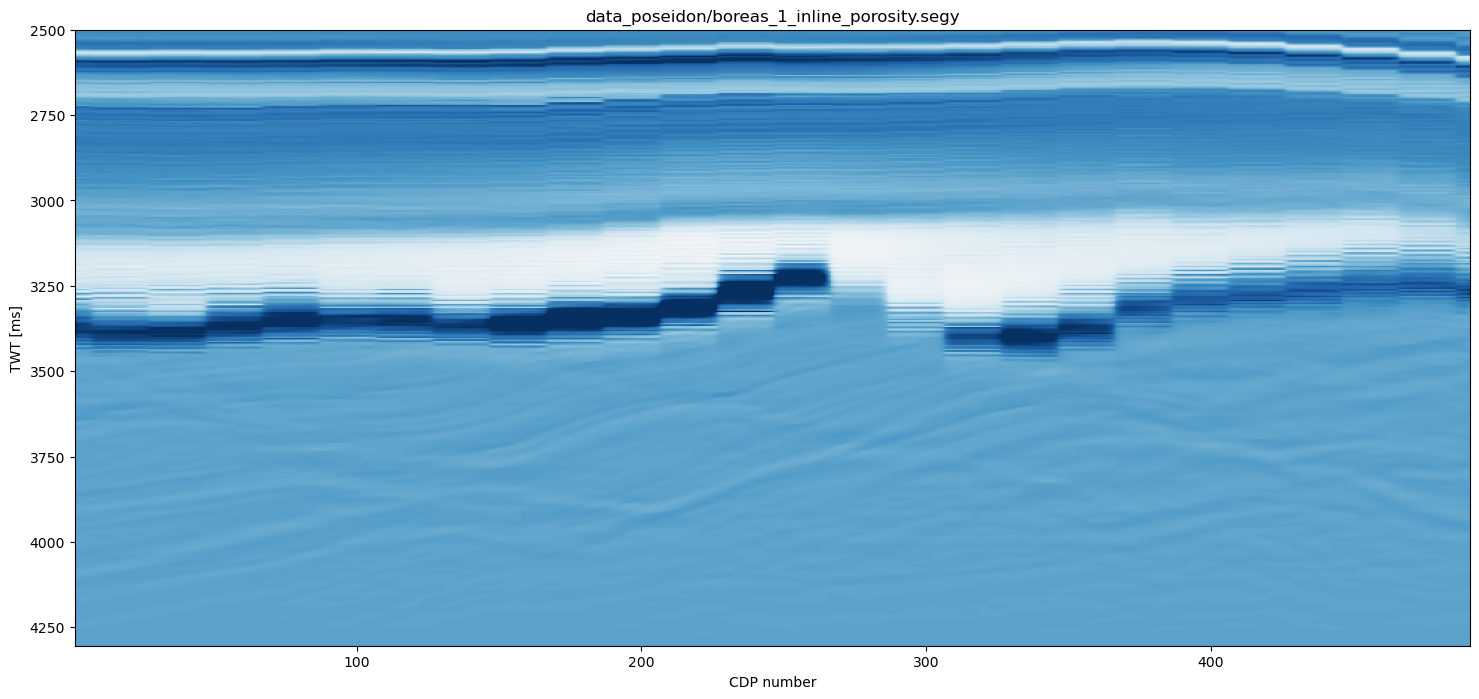

In [35]:
fig = plt.figure(figsize=(18, 8))
ax = fig.add_subplot(1, 1, 1)
extent = [1, n_traces, twt[-1], twt[0]]  # define extent
ax.imshow(data.T, cmap="RdBu", vmin=-vm, vmax=vm, aspect='auto', extent=extent)
ax.set_xlabel('CDP number')
ax.set_ylabel('TWT [ms]')
ax.set_title(f'{filename}')